<a href="https://colab.research.google.com/github/projectgroup398-sudo/NorthStar_Section3_Python_Data_Processing/blob/main/NorthStar_Section3_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Required Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn

# Upload CSV Files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load Datasets

In [ ]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
complaints = pd.read_csv("complaints.csv")
app_events = pd.read_csv("app_events.csv")
incidents = pd.read_csv("incidents.csv")

customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


# Data Cleaning and Standardisation

In [ ]:
customers["home_zone"] = customers["home_zone"].str.upper()
orders["pickup_zone"] = orders["pickup_zone"].str.upper()
orders["dropoff_zone"] = orders["dropoff_zone"].str.upper()
drivers["base_zone"] = drivers["base_zone"].str.upper()
vehicles["assigned_zone"] = vehicles["assigned_zone"].str.upper()
app_events["zone_context"] = app_events["zone_context"].str.upper()

# Analysis 1 – Demand Distribution by Zone

Objective

Identify zones with highest service demand.

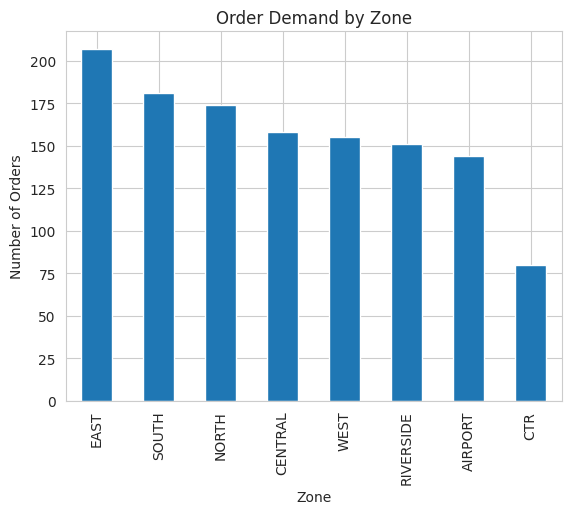

,count
pickup_zone,
EAST,207
SOUTH,181
NORTH,174
CENTRAL,158
WEST,155
RIVERSIDE,151
AIRPORT,144
CTR,80


In [ ]:
zone_demand = orders["pickup_zone"].value_counts()

zone_demand.plot(kind="bar")
plt.title("Order Demand by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Orders")
plt.show()

zone_demand

# Analysis 2 – Average Order Value by Priority Level

Objective

Determine whether priority orders generate higher revenue.

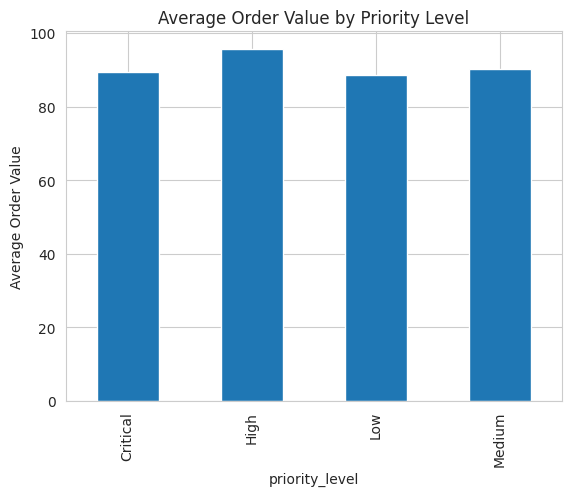

,order_value
priority_level,
Critical,89.384505
High,95.663701
Low,88.657672
Medium,90.182644


In [ ]:
priority_value = orders.groupby("priority_level")["order_value"].mean()

priority_value.plot(kind="bar")
plt.title("Average Order Value by Priority Level")
plt.ylabel("Average Order Value")
plt.show()

priority_value

# Analysis 3 – Customer Engagement Segmentation

Objective

Segment customers based on engagement score.

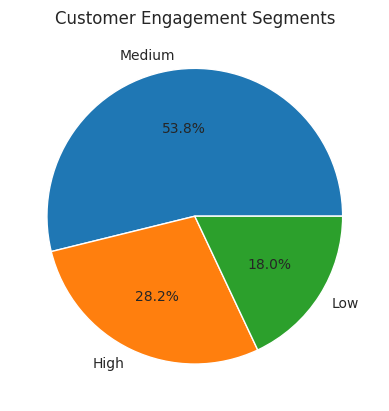

,count
engagement_segment,
Medium,350
High,183
Low,117


In [ ]:
customers["engagement_segment"] = pd.cut(
    customers["app_engagement_score"],
    bins=[0,40,70,100],
    labels=["Low","Medium","High"]
)

segment_counts = customers["engagement_segment"].value_counts()

segment_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Engagement Segments")
plt.ylabel("")
plt.show()

segment_counts

# Analysis 4 – Driver Productivity Indicator

Objective

Identify drivers with high rating and experience.

In [ ]:
drivers["productivity_index"] = (
    drivers["driver_rating"] * drivers["years_experience"]
)

top_drivers = drivers.sort_values(by="productivity_index", ascending=False).head(10)

top_drivers[["driver_id","productivity_index"]]

,driver_id,productivity_index
54,D055,75.00
85,D086,70.00
106,D107,67.48
102,D103,66.00
81,D082,64.82
17,D018,63.98
91,D092,63.60
111,D112,63.14
169,D170,62.72
110,D111,61.80


# Analysis 5 – Complaint Rate per Service Type

Objective

Identify which services generate the most complaints.

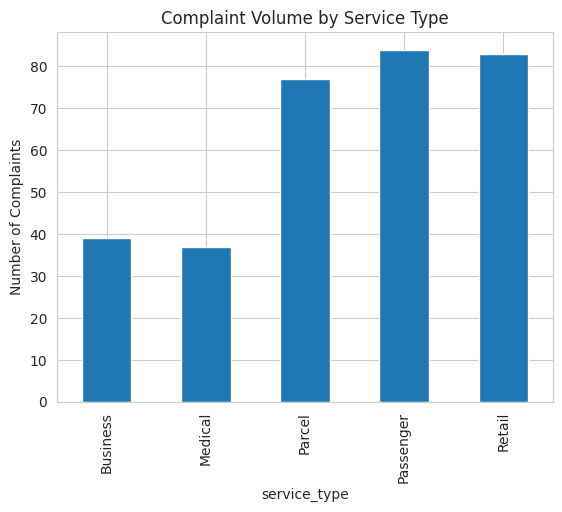

,complaint_id
service_type,
Business,39
Medical,37
Parcel,77
Passenger,84
Retail,83


In [ ]:
merged_data = pd.merge(orders, complaints, on="order_id", how="left")

complaint_rate = merged_data.groupby("service_type")["complaint_id"].count()

complaint_rate.plot(kind="bar")
plt.title("Complaint Volume by Service Type")
plt.ylabel("Number of Complaints")
plt.show()

complaint_rate

# Analysis 6 – App Usage Pattern by Event Type

Objective

Understand most frequent user actions in the mobile app.

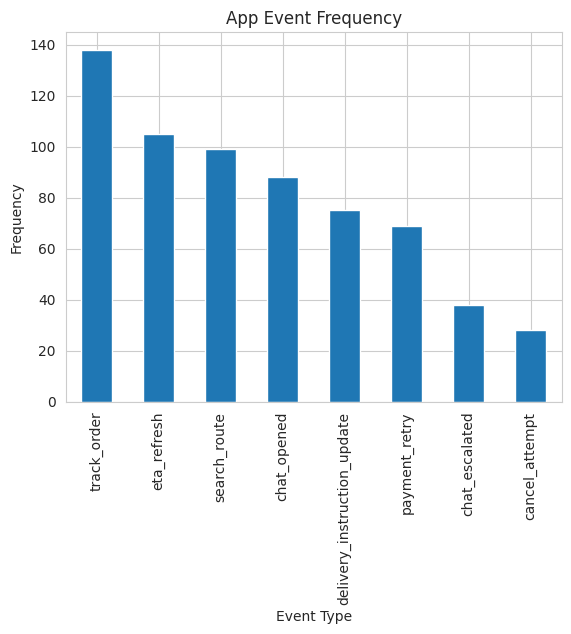

,count
event_type,
track_order,138
eta_refresh,105
search_route,99
chat_opened,88
delivery_instruction_update,75
payment_retry,69
chat_escalated,38
cancel_attempt,28


In [ ]:
event_usage = app_events["event_type"].value_counts()

event_usage.plot(kind="bar")
plt.title("App Event Frequency")
plt.xlabel("Event Type")
plt.ylabel("Frequency")
plt.show()

event_usage

# Analysis 7 – Incident Frequency by Type

Objective

Identify most common operational risks.

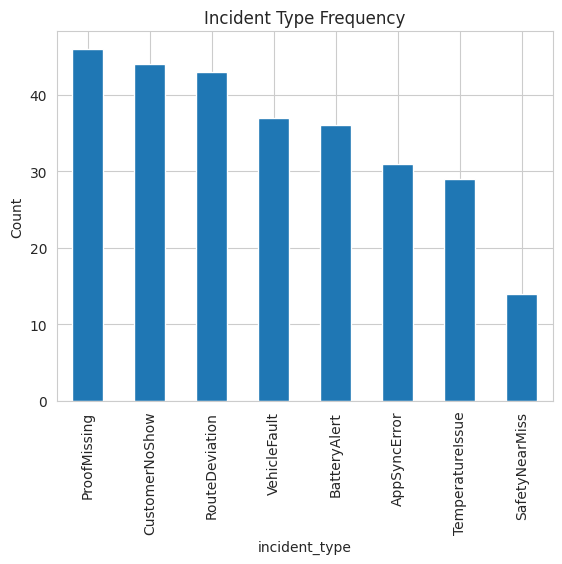

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


In [ ]:
incident_freq = incidents["incident_type"].value_counts()

incident_freq.plot(kind="bar")
plt.title("Incident Type Frequency")
plt.ylabel("Count")
plt.show()

incident_freq